### Algoritmo Genetico

1. **Inicializar población aleatoria**
2. **Evaluar el *Fitness* (aptitud)** de cada individuo

### Ciclo Evolutivo
*Mientras no se cumpla la condición de parada (ej. número de generaciones o convergencia):*

* **3. Selección:** Elegir a los mejores padres (ej. mediante técnicas como torneo o ruleta).
* **4. Cruce (*Crossover*):** Combinar los genes de los padres seleccionados para crear nuevos hijos.
* **5. Mutación:** Alterar aleatoriamente algunos genes de los hijos para mantener la diversidad genética.
* **6. Reemplazo:** Sustituir la población antigua (o parte de ella) para crear la nueva generación de individuos.
* **7. Evaluar el nuevo *Fitness*:** Calcular la aptitud de la nueva generación antes de reiniciar el ciclo.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

Optimizar (minimizar) la función $f(x) = \frac{204165.5}{330 - 2t} + \frac{10400}{t - 20}$

In [2]:
## Funcion a optmizar
fx = lambda t: 204165.5/(330 - 2*t) + 10400/(t-20) 

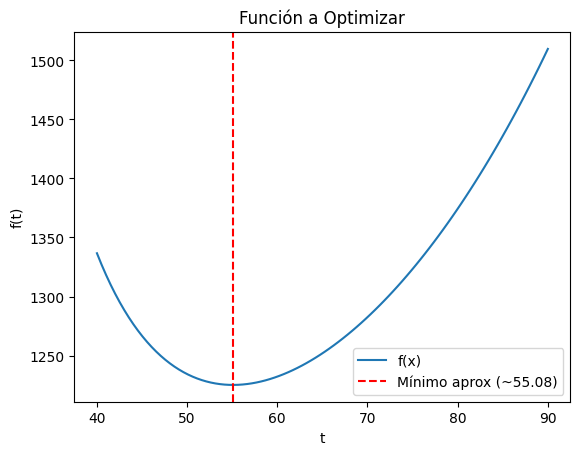

In [3]:
t = np.linspace(40, 90, 100)
plt.plot(t, fx(t), label="f(x)")
plt.axvline(x=55.08, color='r', linestyle='--', label="Mínimo aprox (~55.08)") 
plt.title("Función a Optimizar")
plt.xlabel("t")
plt.ylabel("f(t)")
plt.legend()
plt.show()

In [4]:
nbits = 8                 # Longitud del cromosoma
n_individuos = 10         # Tamaño de la población (debe ser par para la cruza)
p_cruza = 0.7              # Probabilidad de cruza
p_mutacion = 0.04          # Probabilidad de mutación por gen
generaciones = 50          # Número de iteraciones del algoritmo

# Matriz de potencias de 2 para decodificación binario -> decimal
pow2 = 2 ** np.arange(nbits - 1, -1, -1)
max_value = 2**nbits - 1
print(pow2)
print(max_value)

[128  64  32  16   8   4   2   1]
255


In [5]:
# Programa la seleccion de Torneo 
# Cruza con una probabilidad de 0.7
# Mutar con una probabilidad de 0.04

In [6]:
def decodificar_y_evaluar(poblacion):
    # Convertir a decimales usando el producto punto
    poblacion_decimales = np.dot(poblacion, pow2)
    # Mapear al rango [40, 90]
    x = 40 + (90 - 40) * poblacion_decimales / max_value
    # Calcular el fitness
    fitness = fx(x)
    return x, fitness

In [7]:
def seleccion_torneo(poblacion, fitness, k=3):
    nueva_poblacion = []
    for _ in range(len(poblacion)):
        # Escoger k rivales al azar
        aspirantes_idx = np.random.choice(len(poblacion), size=k, replace=False)
        # Buscar cuál de los aspirantes tiene el MENOR fitness (porque estamos minimizando)
        mejor_idx = aspirantes_idx[np.argmin(fitness[aspirantes_idx])]
        nueva_poblacion.append(poblacion[mejor_idx].copy())
    return np.array(nueva_poblacion)

def cruza_un_punto(poblacion, p_cruza):
    poblacion_hijos = []
    # Emparejar de dos en dos
    for i in range(0, len(poblacion), 2):
        padre1 = poblacion[i]
        padre2 = poblacion[i+1]
        
        if random.random() < p_cruza:
            # Elegir un punto de corte aleatorio (entre el bit 1 y nbits-1)
            punto = random.randint(1, nbits - 1)
            # Combinar los genes
            hijo1 = np.concatenate((padre1[:punto], padre2[punto:]))
            hijo2 = np.concatenate((padre2[:punto], padre1[punto:]))
        else:
            # Si no se cruzan, pasan intactos
            hijo1 = padre1.copy()
            hijo2 = padre2.copy()
            
        poblacion_hijos.append(hijo1)
        poblacion_hijos.append(hijo2)
    return np.array(poblacion_hijos)

def mutacion_por_bit(poblacion, p_mutacion):
    for i in range(len(poblacion)):
        for j in range(nbits):
            if random.random() < p_mutacion:
                # Invertir el bit (si es 0 pasa a 1, si es 1 pasa a 0)
                poblacion[i][j] = 1 - poblacion[i][j]
    return poblacion

In [16]:
# se inizializa la población aleatoria
poblacion = np.random.randint(0, 2, size=(n_individuos, nbits))

historial_mejor_fitness = []

for gen in range(generaciones):
    # evaluar el Fitness actual
    x, fitness = decodificar_y_evaluar(poblacion)
    idx_mejor = np.argmin(fitness)
    mejor_f = fitness[idx_mejor]
    mejor_x = x[idx_mejor]
    historial_mejor_fitness.append(mejor_f)
    # aplicar la selección por Torneo
    poblacion_seleccionada = seleccion_torneo(poblacion, fitness, k=3)
    # hacer el cruce (Crossover)
    poblacion_hijos = cruza_un_punto(poblacion_seleccionada, p_cruza)
    # Mutación 
    poblacion = mutacion_por_bit(poblacion_hijos, p_mutacion)
    
    if gen % 5 == 0 or gen == generaciones - 1:
        print(f"Gen {gen:02d} -> Mejor x: {mejor_x:.4f} | Mínimo Fitness f(x): {mejor_f:.4f}")
        # print(poblacion)


x_final, fitness_final = decodificar_y_evaluar(poblacion)
idx_mejor_final = np.argmin(fitness_final)

print(f"Mejor valor encontrado para t (x): {x_final[idx_mejor_final]:.4f}")
print(f"Valor mínimo de la función f(t): {fitness_final[idx_mejor_final]:.4f}")
print(f"Cromosoma óptimo: {poblacion[idx_mejor_final]}")

Gen 00 -> Mejor x: 55.2941 | Mínimo Fitness f(x): 1225.1797
Gen 05 -> Mejor x: 55.2941 | Mínimo Fitness f(x): 1225.1797
Gen 10 -> Mejor x: 54.9020 | Mínimo Fitness f(x): 1225.1761
Gen 15 -> Mejor x: 55.0980 | Mínimo Fitness f(x): 1225.1657
Gen 20 -> Mejor x: 55.0980 | Mínimo Fitness f(x): 1225.1657
Gen 25 -> Mejor x: 55.0980 | Mínimo Fitness f(x): 1225.1657
Gen 30 -> Mejor x: 55.0980 | Mínimo Fitness f(x): 1225.1657
Gen 35 -> Mejor x: 55.0980 | Mínimo Fitness f(x): 1225.1657
Gen 40 -> Mejor x: 55.0980 | Mínimo Fitness f(x): 1225.1657
Gen 45 -> Mejor x: 55.0980 | Mínimo Fitness f(x): 1225.1657
Gen 49 -> Mejor x: 55.0980 | Mínimo Fitness f(x): 1225.1657
Mejor valor encontrado para t (x): 55.0980
Valor mínimo de la función f(t): 1225.1657
Cromosoma óptimo: [0 1 0 0 1 1 0 1]


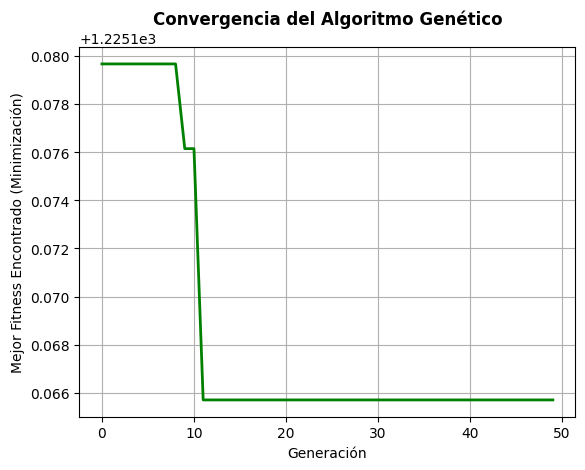

In [17]:
plt.figure()
plt.plot(historial_mejor_fitness, color='green', linewidth=2) 
plt.title("Convergencia del Algoritmo Genético", fontweight='bold') 
plt.xlabel("Generación")
plt.ylabel("Mejor Fitness Encontrado (Minimización)")
plt.grid(True)
plt.show()